# Vehicle Fuel Efficiency Analysis

## Project overview

This case study explores how vehicle characteristics are related to fuel efficiency. The analysis focuses on **miles per gallon (MPG)** and examines its relationship with engine displacement, horsepower, vehicle weight, acceleration, model year, origin and cylinder count.

**Business-style question:** Which vehicle characteristics are most strongly associated with fuel efficiency, and what patterns can be identified across different vehicle groups?

**Methods:** data preparation, descriptive statistics, exploratory data analysis, visualisation, Pearson correlation, cross-tabulation and pairwise analysis.

### Key findings
- MPG had a strong negative correlation with vehicle weight (about **-0.81**).
- MPG had a strong negative correlation with engine displacement (about **-0.81**).
- Horsepower and displacement had a strong positive correlation (about **0.93**).

The notebook uses a sample of the Auto MPG dataset and is presented as an applied analytical case study.


## Dataset

The Auto-MPG data is a compilation of vehicle characteristics used at the 1983 American Statistical Association show and taken from Carnegie Mellon University's StatLib repository. Miles per gallon is the main metric in the data set, which combines three multi-valued discrete and five continuous variables for 398 vehicles.

Data analysis will assist users to comprehend the links and distributions inside a data set, addressing significant business challenges such as:

How does a vehicle's size and power affect its fuel efficiency?

Are there any vehicle features that distinguish a specific subset of the dataset, such as sports cars or utility vehicles?

Which variables may have the most influence if we were to estimate fuel efficiency?

## Data preparation and dataset structure

Dataset Description
The first few lines provide a sense of the numerous attributes and the data set's intricate structure:
*   MPG (miles per gallon): Measures fuel economy.
*   Cylinders: The number of cylinders in an automobile engine.
*   Displacement: Engine displacement.
*   Horsepower is the engine's power output.
*   Weight of the automobile.
*   Acceleration refers to the car's capacity to accelerate.
*   Model year refers to the year of the automotive model.
*   Origin: Identifies the automobile manufacturer's origin.
*   Car model has its own distinctive name.



In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

import pandas as pd

# Load the dataset from the local file path
file_path = "../data/auto_mpg.csv"
auto_mpg_df = pd.read_csv(file_path)

# Display the column names of the dataframe
print("The attributes are:")
for col in auto_mpg_df.columns:
    print(col)

# Define the corrections needed
corrections = {
    "vw": "volkswagen",
    "chevroelt": "chevrolet"
}

# Function to apply corrections
def correct_model_name(model):
    split_model = model.lower().split(' ')[0]
    corrected = corrections.get(split_model, split_model)
    # Replacing only the first occurrence in case of partial match
    return model.lower().replace(split_model, corrected, 1)

# Correct the car model names in the DataFrame
auto_mpg_df['Car model'] = auto_mpg_df['Car model'].apply(correct_model_name)

# Save the corrected DataFrame to a new CSV file
corrected_file_path = "../data/auto_mpg_cleaned.csv"
auto_mpg_df.to_csv(corrected_file_path, index=False)

The attributes are:
mpg
cylinders
displacement
horsepower
weight
acceleration
model year
origin
Car model


In [ ]:
auto_mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,Car model
0,15.0,8,390,190,3850,8.5,70,1,amc
1,24.0,4,107,90,2430,14.5,70,2,audi
2,25.0,4,104,95,2375,17.5,70,2,saab
3,19.0,6,232,100,2634,13.0,71,1,amc
4,14.0,8,400,175,4464,11.5,71,1,pontiac


## Variable types

The data set's variables are classified as categorical or continuous in order to suit the analytic methods utilised. This separation will allow you to better grasp the nature of the data and choose appropriate visualisation and modelling tools.

Based on the dataset description and initial observation, we can classify the variables as follows:

**Categorical variables**: cylinders, model year, origin, Car model

**Continuous variables**: mpg, displacement, horsepower, weight, acceleration

**Categorical Variables**:

**Cylinders**: reflects the number of cylinders in an automobile engine. It is classed as a categorical variable since the number of cylinders (4, 6, 8) reflects separate categories rather than a continuous spectrum.

**Model Year**: automobile model year is a categorical variable that shows the year the automobile was manufactured. Cars manufactured in the same year fall into the same category.

**Origin**: This variable indicates the region where the vehicle was manufactured. It is a categorical variable since it divides autos into groups depending on origin.

**Automobile model**. Car model name is a categorical variable because it classifies automobiles based on their model names, despite the fact that it has a huge number of unique values.

**Continuous Variables**:

**MPG** (miles per gallon): This is a continuous variable that measures the vehicle's fuel economy and can take any value within a given range. MPG may be measured to the decimal point, demonstrating its continuous nature.

**Engine Displacement**: This variable is continuous because it may reflect engine displacement across a large range of values.

**Horsepower**: This variable indicates the power output of a car's engine and is a continuous variable since it may fluctuate by a decimal point, signifying engine power levels.

**Weight**: A vehicle's weight is a continuous variable since it may change greatly and be monitored precisely.

**Acceleration**: This variable measures how long it takes an automobile to accelerate from a stop to a specific speed. It is continuous because the acceleration can change endlessly within the range, ensuring precise measurement.


In [ ]:
# Set up lists to contain the names of categorical and continuous variables.
categorical_vars = []
continuous_vars = []

# Define known categorical variables that are coded numerically
explicitly_categorical = ['cylinders', 'model year', 'origin']

# Classify each column in the DataFrame according to its data type and semantic meaning.
for col in auto_mpg_df.columns:
    if col in explicitly_categorical:
        categorical_vars.append(col)
    elif auto_mpg_df[col].dtype == 'object':
        categorical_vars.append(col)
    elif auto_mpg_df[col].dtype in ['int64', 'float64']:
        continuous_vars.append(col)

# Output the results
print("Categorical Variables:", categorical_vars)
print("Continuous Variables:", continuous_vars)

Categorical Variables: ['cylinders', 'model year', 'origin', 'Car model']
Continuous Variables: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Descriptive statistics for continuous variables

This phase summarises a data set's central tendency, variance, and distribution shape while removing unknown values. Helps us comprehend the structure of your data collection and uncover trends or abnormalities that warrant additional research.

The descriptive statistics for the continuous variables in the dataset are as follows:

**Count**: Displays the number of values in each column, giving a notion of how complete the data is.

**Mean**: The average of all records for each variable, providing a rapid indication of central tendency.

**Std** (standard deviation): The amount by which values depart from the mean, demonstrating the data set's variability.

**Min**: The minimum value in each column indicates the lowest data range.

**25%** (first quartile): This figure indicates the bottom quartile and provides insight into the data distribution.

**50%** (median): The average number that splits the data in half to assist determine central tendency.

**75%** (third quartile): The number below which 75% of the data falls, representing the top quartile.

**Max**: The highest number used to comprehend the data set's top range.

**Var** (variance): quantifies the departure from the mean, providing information on the distribution of the data.

**Range**: the difference between the maximum and minimum values.

In [ ]:
# Calculate descriptive statistics for continuous variables
continuous_columns = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
desc_stats_cont = auto_mpg_df[continuous_columns].describe()

# Add variance and range (max-min) as these are not included by default in describe()
desc_stats_cont.loc['variance'] = auto_mpg_df[continuous_columns].var()
desc_stats_cont.loc['range'] = desc_stats_cont.loc['max'] - desc_stats_cont.loc['min']

desc_stats_cont

,mpg,displacement,horsepower,weight,acceleration
count,54.000000,54.000000,54.000000,54.000000,54.000000
mean,24.644444,194.740741,102.111111,3024.351852,15.874074
std,9.361355,107.512559,37.915331,912.261944,3.378298
min,11.000000,85.000000,48.000000,1800.000000,8.500000
25%,17.125000,98.000000,75.250000,2260.000000,13.650000
50%,23.250000,148.500000,95.000000,2654.500000,15.000000
75%,30.350000,293.250000,134.750000,3740.250000,17.650000
max,44.600000,429.000000,198.000000,4997.000000,24.600000
variance,87.634969,11558.950384,1437.572327,832221.854997,11.412900
range,33.600000,344.000000,150.000000,3197.000000,16.100000


Data analysis gives extensive insight into the composition of data on vehicle performance and characteristics:

**MPG**: The data set includes 54 cars, displaying fuel economy ranging from 11 to 44.6 mpg. The mean mpg is 24.64, but the dispersion (standard deviation 9.36) implies significant variation between models. The mpg range of 33.6 indicates a substantial disparity in the fuel efficiency of the vehicles.

**Displacement**: Engine sizes in cars range from 85 to 429 cubic inches, with an average displacement of 194.74. The standard deviation of 107.51 implies a diversified collection of engines, as seen by the 344 range.

**Power**: The data set has an average power of 102.11, with values ranging from 48 to 198. The standard deviation of 37.91 emphasises the mix of powerful engines and high-performance engines, as seen by the 150 horsepower range.

**Weight**: 1,800–4,997 pounds, with an average of 3,024.35 pounds. The dataset includes both small and large cars with a weight range of 3197, as seen by the huge standard deviation of 912.26.

**Acceleration**: ranges from 8.5 to 24.6 seconds, with a mean of 15.87. The standard deviation of 3.38 seconds reveals that performance levels vary between models, as indicated by the acceleration range of 16.1 seconds.




## Categorical distributions

This phase of our research focuses on breaking down our dataset's categorical variables to disperse essential vehicle attributes. To this goal, we choose a frequency distribution for analytical reasons.

Frequency distribution across multiple categories:

**Cylinders**: 4-cylinder engines are the most prevalent (27 automobiles), followed by 8-cylinder (15 cars), 6-cylinder (10 cars), and a small number of 5-cylinder engines (2 cars). We may presume that four-cylinder engines are more popular because of their efficiency and power.

**Model Year**: Vehicles are built between 1970 and 1982, with obvious grouping by year. 1980 leads with seven cars, followed by 1978 and 1979 with six each. This distribution highlights times of increased output, which represent the car industry's characteristics.

**Origin**: The results reveal a strong dominance of region 1 (33 cars), which might indicate market preferences or manufacturing centres. Regions 2 and 3 also add to the dataset's variety, with 14 and 7 automobiles respectively.

**Car Model**: Displays a diverse selection of cars, with Ford, Volkswagen and Chevrolet dominating (by 7 times). AMC, Plymouth, and Volkswagen all appear significantly. This demonstrates the competitive nature of the car business.

This research provides a statistical foundation for evaluating current trends and preferences in a dataset that shows broad patterns in vehicle manufacturing and market impact.



In [ ]:
# Categorical variables
categorical_vars = ['cylinders', 'model year', 'origin', 'Car model']

# Calculate frequency distributions for existing categorical variables in the DataFrame
for var in categorical_vars:
    if var in auto_mpg_df.columns:  # Check if the variable is in the DataFrame
        frequency_distribution = auto_mpg_df[var].value_counts()
        print(f"Frequency distribution for {var}:")
        print(frequency_distribution)
        print("\n")
    else:
        print(f"{var} is not a column in the DataFrame.\n")

Frequency distribution for cylinders:
cylinders
4    27
8    15
6    10
5     2
Name: count, dtype: int64


Frequency distribution for model year:
model year
80    7
78    6
79    6
81    5
71    4
72    4
75    4
77    4
82    4
70    3
73    3
74    2
76    2
Name: count, dtype: int64


Frequency distribution for origin:
origin
1    33
2    14
3     7
Name: count, dtype: int64


Frequency distribution for Car model:
Car model
ford           7
volkswagen     7
chevrolet      7
amc            4
plymouth       4
audi           3
datsun         3
mercury        3
honda          2
dodge          2
buick          2
toyota         2
pontiac        2
chrysler       2
volvo          1
mercedes       1
saab           1
triumph        1
Name: count, dtype: int64




## Data visualisation

### Histograms

In this analysis segment, we will visualise variable values to better grasp the data set's subtleties.
Visualising data with histograms can help us discover patterns in the distribution of important vehicle parameters and highlight critical trends.

Based on the findings of visual analysis utilising histograms, we noticed the following points:

**MPG**: The miles per gallon (MPG) distribution is biassed to the right, showing that the majority of cars achieve lower MPG.

**Displacement**: Has a right-hand distribution, indicating that smaller engines are increasingly popular, while larger engines remain in demand.

**Power**: The power distribution is somewhat biassed to the right, showing a greater demand for low-power cars and less high-powered vehicles.

**Weight**: Distributed on the right side: most automobiles are lighter, which is most likely owing to the fact that cars with less capacity require a lesser weight.

**Acceleration**: Has a more symmetrical distribution than other variables, showing a balanced distribution of acceleration values among vehicles.

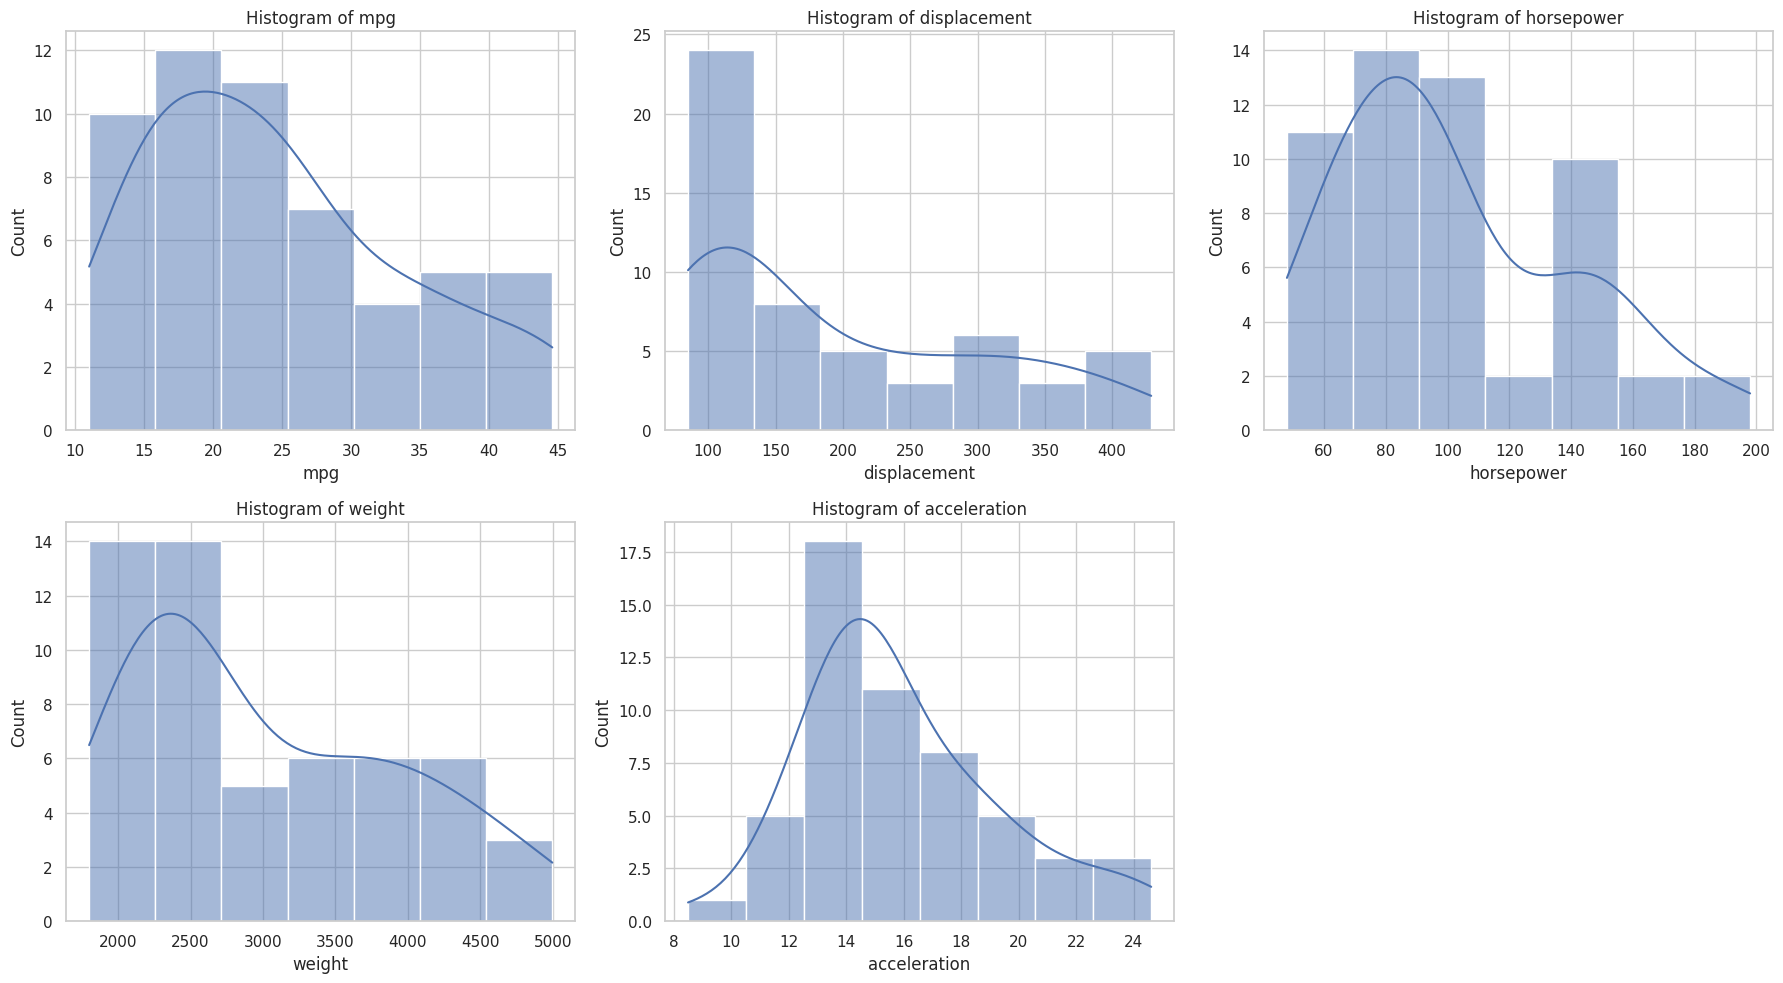

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics for the plots
sns.set(style="whitegrid")

# Histograms for continuous variables
plt.figure(figsize=(18, 10))

for i, col in enumerate(continuous_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(auto_mpg_df[col], kde=True)
    plt.title(f'Histogram of {col}')

plt.tight_layout()

# Display the plots
plt.show()

  ### Box plots

In the following phase of our analysis, we choose box plots since they are a dependable means of depicting the distribution of continuous data. Boxplots visually summarise the median, quartiles, and outliers, allowing you to easily discover centre values as well as dispersion, skewness, and outlier observations within a variable.

Based on the findings of visual analysis utilising Box-plots, we observed the following:

**MPG**: The graph displays a figure in the midst of 20 and 25, but with greater emissions, indicating that there are fuel-efficient cars that deviate from the norm.

**Displacement**: The distribution is broad, indicating considerable variations in engine displacement. The longer frame implies that engine sizes are evenly distributed over the interquartile range, including both economy and performance cars.

**Horsepower**: This graph displays greater emissions, showing that numerous cars have more horsepower. These might be models with strong engines that set them apart from normal cars.

**Weight**: The weight distribution is biassed towards the lighter side, with the box extending further to the lighter side of the median. This imbalance suggests that the data set contains more light cars, which have lower MPG.

**Acceleration**. The boxplot reveals a fairly symmetrical distribution, with minor asymmetry showing automobiles that take much longer to accelerate. This displays cars with less powerful engines, assuming the same weight and power indications.

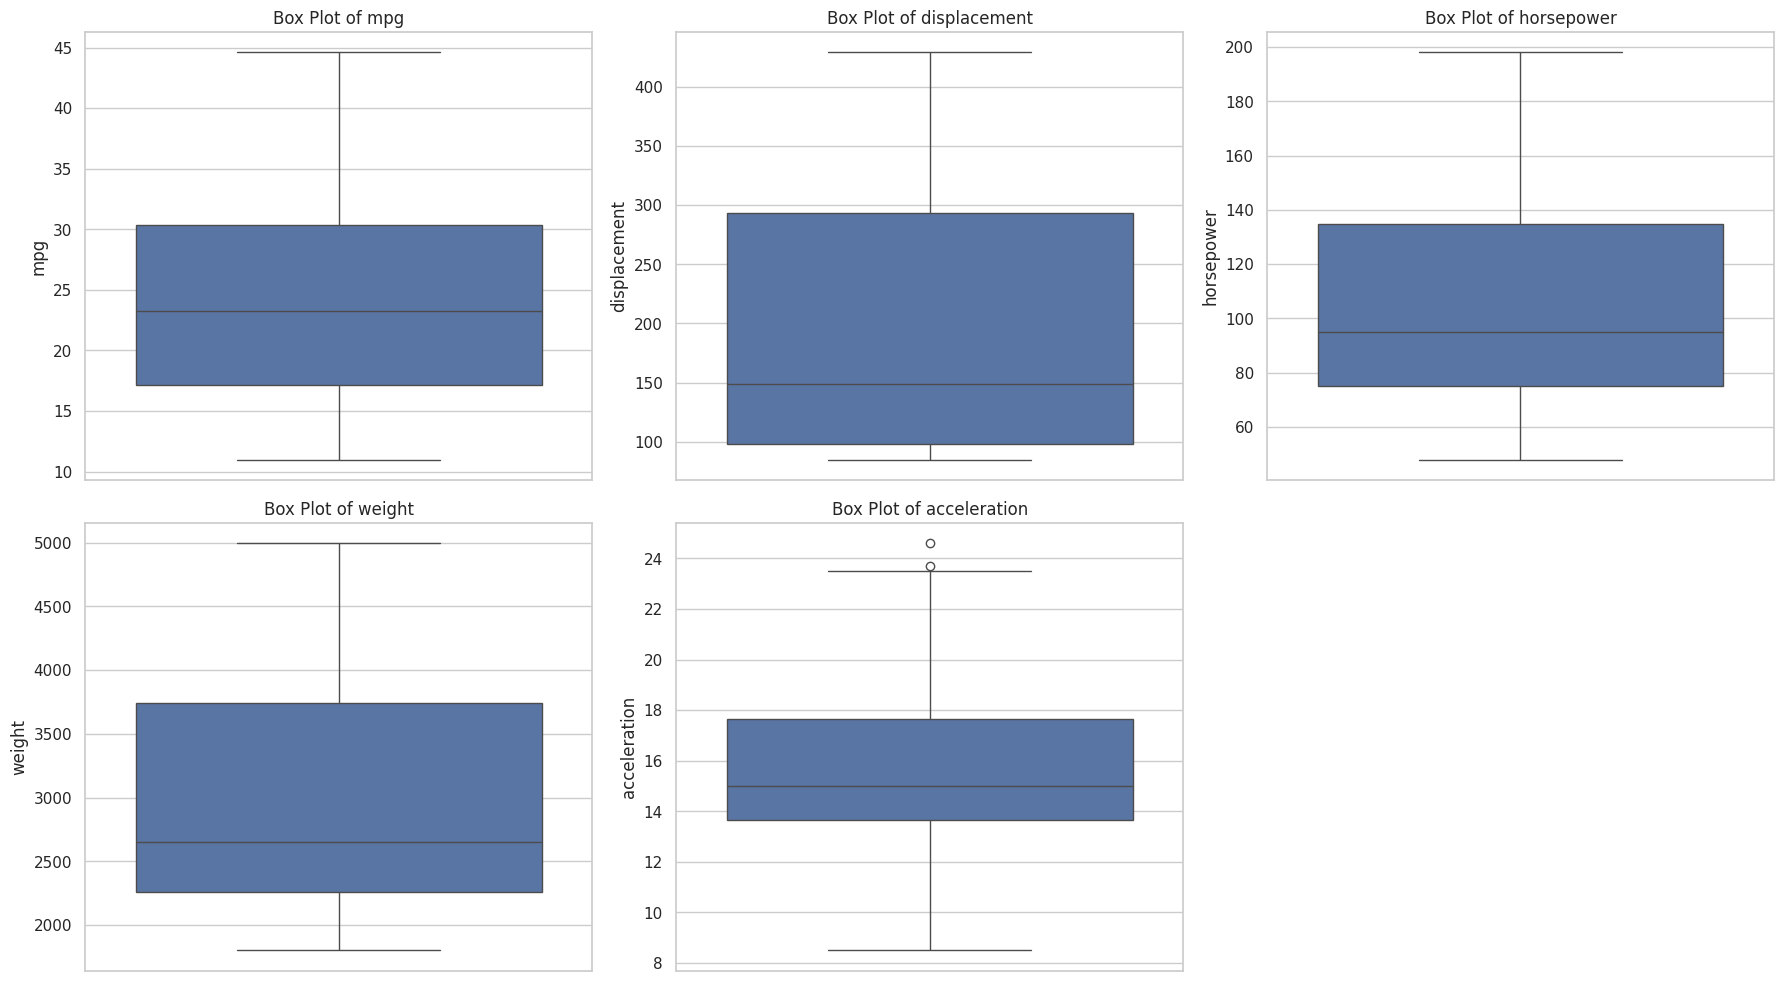

In [ ]:
# Box plots for continuous variables
plt.figure(figsize=(18, 10))

for i, col in enumerate(continuous_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=auto_mpg_df[col])
    plt.title(f'Box Plot of {col}')

plt.tight_layout()

# Display the plots
plt.show()

  ### Bar charts

In the following section of our analysis, we use bar charts to visualise the frequency of categorical variables. This strategy allows us to readily distinguish between the most and least common situations in each category.

Based on the results of a visual examination using bar charts, we discovered the following:

**Cylinders**: According to the histogram, 4-cylinder engines are the most prevalent in the dataset, indicating more fuel-efficient vehicles. Next in popularity are 8-cylinder vehicles, which are more accurate but less efficient.

**Model Year**: The car distribution by model-year indicates a distinct preference for the 1980 model year. This peak may reflect an increase in car sales and demand during that period.

**Origin**: The prevalence of automobiles from Origin Region 1 indicates a market preference for vehicles from that region.

**Car model**: The chart depicts several automobile models, with Ford and Chevrolet being the most frequent. This predominance might be attributed to the dominance of certain brands in the market.




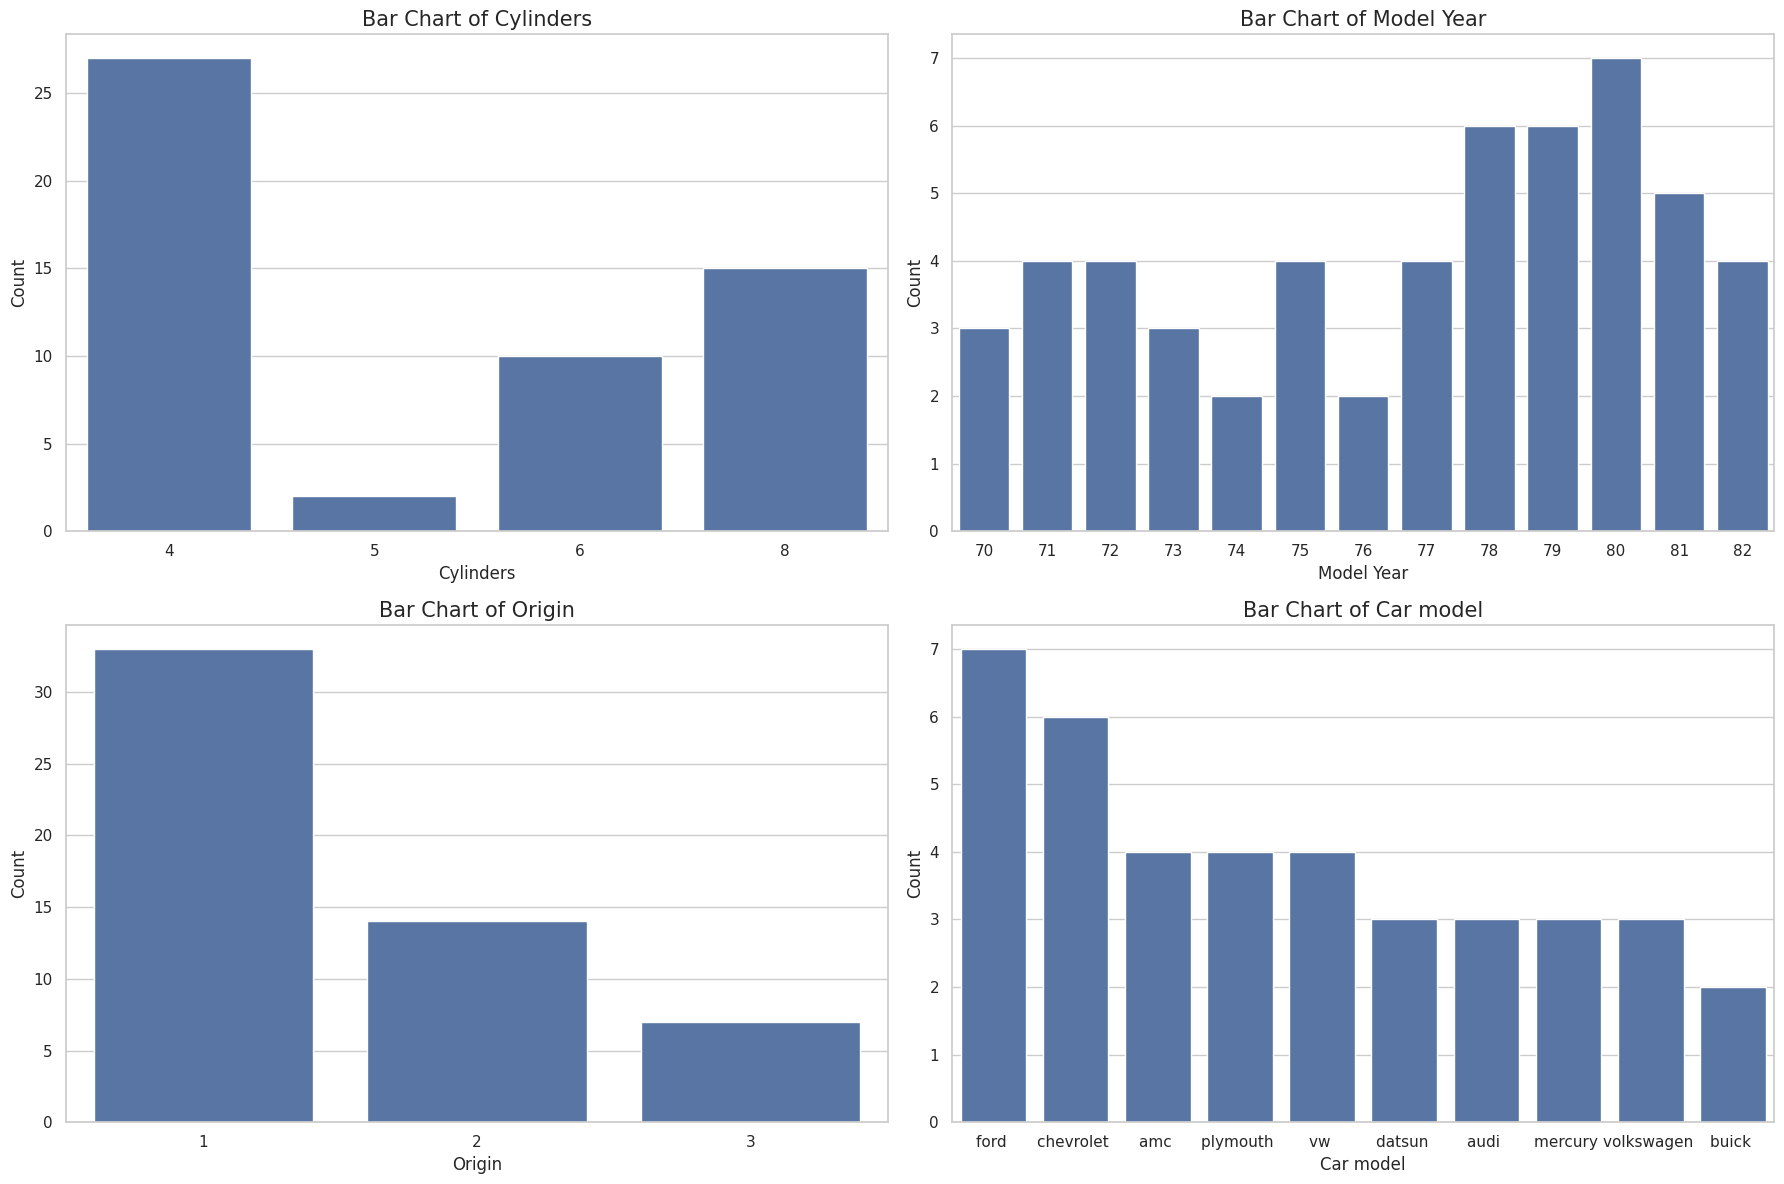

In [ ]:
# Bar charts for categorical variables
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Cylinders
sns.countplot(x='cylinders', data=auto_mpg_df, ax=axs[0, 0])
axs[0, 0].set_title('Bar Chart of Cylinders', fontsize=15)
axs[0, 0].set_xlabel('Cylinders', fontsize=12)
axs[0, 0].set_ylabel('Count', fontsize=12)

# Model Year
sns.countplot(x='model year', data=auto_mpg_df, ax=axs[0, 1])
axs[0, 1].set_title('Bar Chart of Model Year', fontsize=15)
axs[0, 1].set_xlabel('Model Year', fontsize=12)
axs[0, 1].set_ylabel('Count', fontsize=12)

# Origin
sns.countplot(x='origin', data=auto_mpg_df, ax=axs[1, 0])
axs[1, 0].set_title('Bar Chart of Origin', fontsize=15)
axs[1, 0].set_xlabel('Origin', fontsize=12)
axs[1, 0].set_ylabel('Count', fontsize=12)

# Car model - showing only top 10 due to space limitations
top_car_models = auto_mpg_df['Car model'].value_counts().head(10)
sns.barplot(x=top_car_models.index, y=top_car_models.values, ax=axs[1, 1])
axs[1, 1].set_title('Bar Chart of Car model', fontsize=15)
axs[1, 1].set_xlabel('Car model', fontsize=12)
axs[1, 1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

  ### Fuel efficiency by model year

In the following section of our analysis, we choose line graph analysis since it is good at displaying changes over time, offering a visual depiction of how a variable such as MPG evolves over time.

Based on the findings of a visual investigation utilising a line graph, we found the following:

**Trend**: Average fuel efficiency per gallon has been steadily increasing, particularly after 1976, implying that automobiles from this model year have grown more fuel-efficient, which can be attributed to a market move towards more fuel-efficient vehicles.

**Volatility**: Year-to-year changes are visible, demonstrating variability in fuel standards, with a sharp drop around 1973 reflecting the impact of the oil crisis, which looked to produce a short-term reversal of MPG trends.

**Anomalies**: A strong peak in 1980 followed by a decrease suggests abnormalities. This might be due to the use of exceptionally cost-effective (or unsuccessful) models, which warrants more investigation.

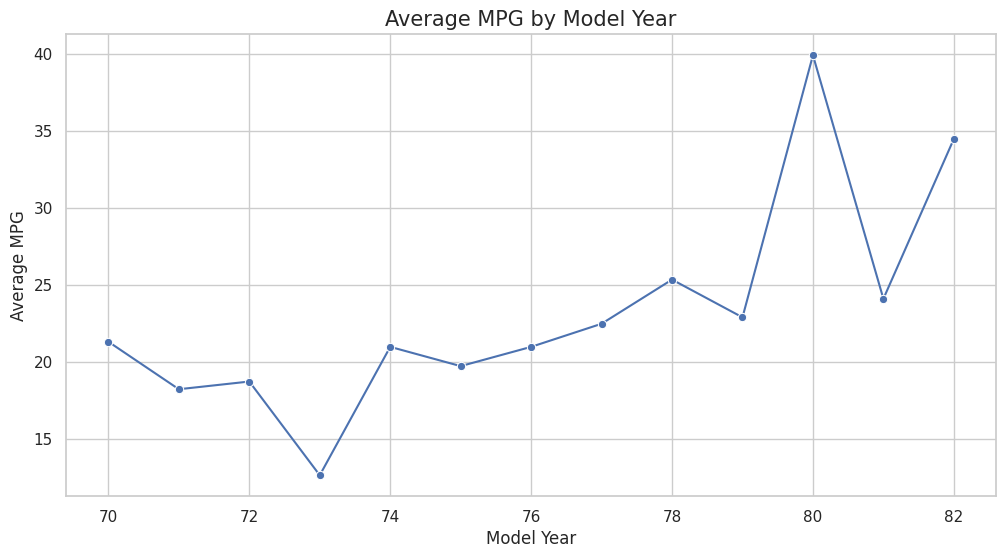

In [ ]:
# Calculating average MPG for each model year
avg_mpg_by_year = auto_mpg_df.groupby('model year')['mpg'].mean().reset_index()

# Creating a line chart to visualize the trend of average MPG over the model years
plt.figure(figsize=(12, 6))
sns.lineplot(x='model year', y='mpg', data=avg_mpg_by_year, marker='o')
plt.title('Average MPG by Model Year', fontsize=15)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Average MPG', fontsize=12)
plt.grid(True)
plt.show()

## Relationships between variables

### Scatter plots and Pearson correlations

In the following section of our analysis, we choose Scatter plots, when paired with Pearson correlation coefficients, aid in determining the strength and correlations between continuous data. We can see how one variable relates to another, and the correlation coefficient quantifies this link.

Based on the findings of a visual investigation utilising a line graph, we found the following:

**MPG vs. Weight**: The graph indicates that as a vehicle's weight grows, fuel economy per gallon declines, which is consistent with our notion that bigger cars take more energy to run and are less fuel efficient. The Pearson correlation value of -0.807 verifies this finding by demonstrating an inverse link.

**MPG vs. Displacement**: Vehicles with bigger engine displacement get lower MPG. Thus, the anticipated negative correlation is -0.806, indicating a significant inverse association.

**Horsepower vs. Displacement**: There is a correlation between engine size and power output. The correlation value of 0.935 verifies the positive association, implying that engine size is a predictor of vehicle power.

**Acceleration vs. Horsepower**: A scatterplot shows a collection of dots with a decreasing trend, demonstrating that cars with greater horsepower have faster acceleration. A Pearson value of -0.732 indicates substantial feedback, showing that variables other than power affect acceleration.

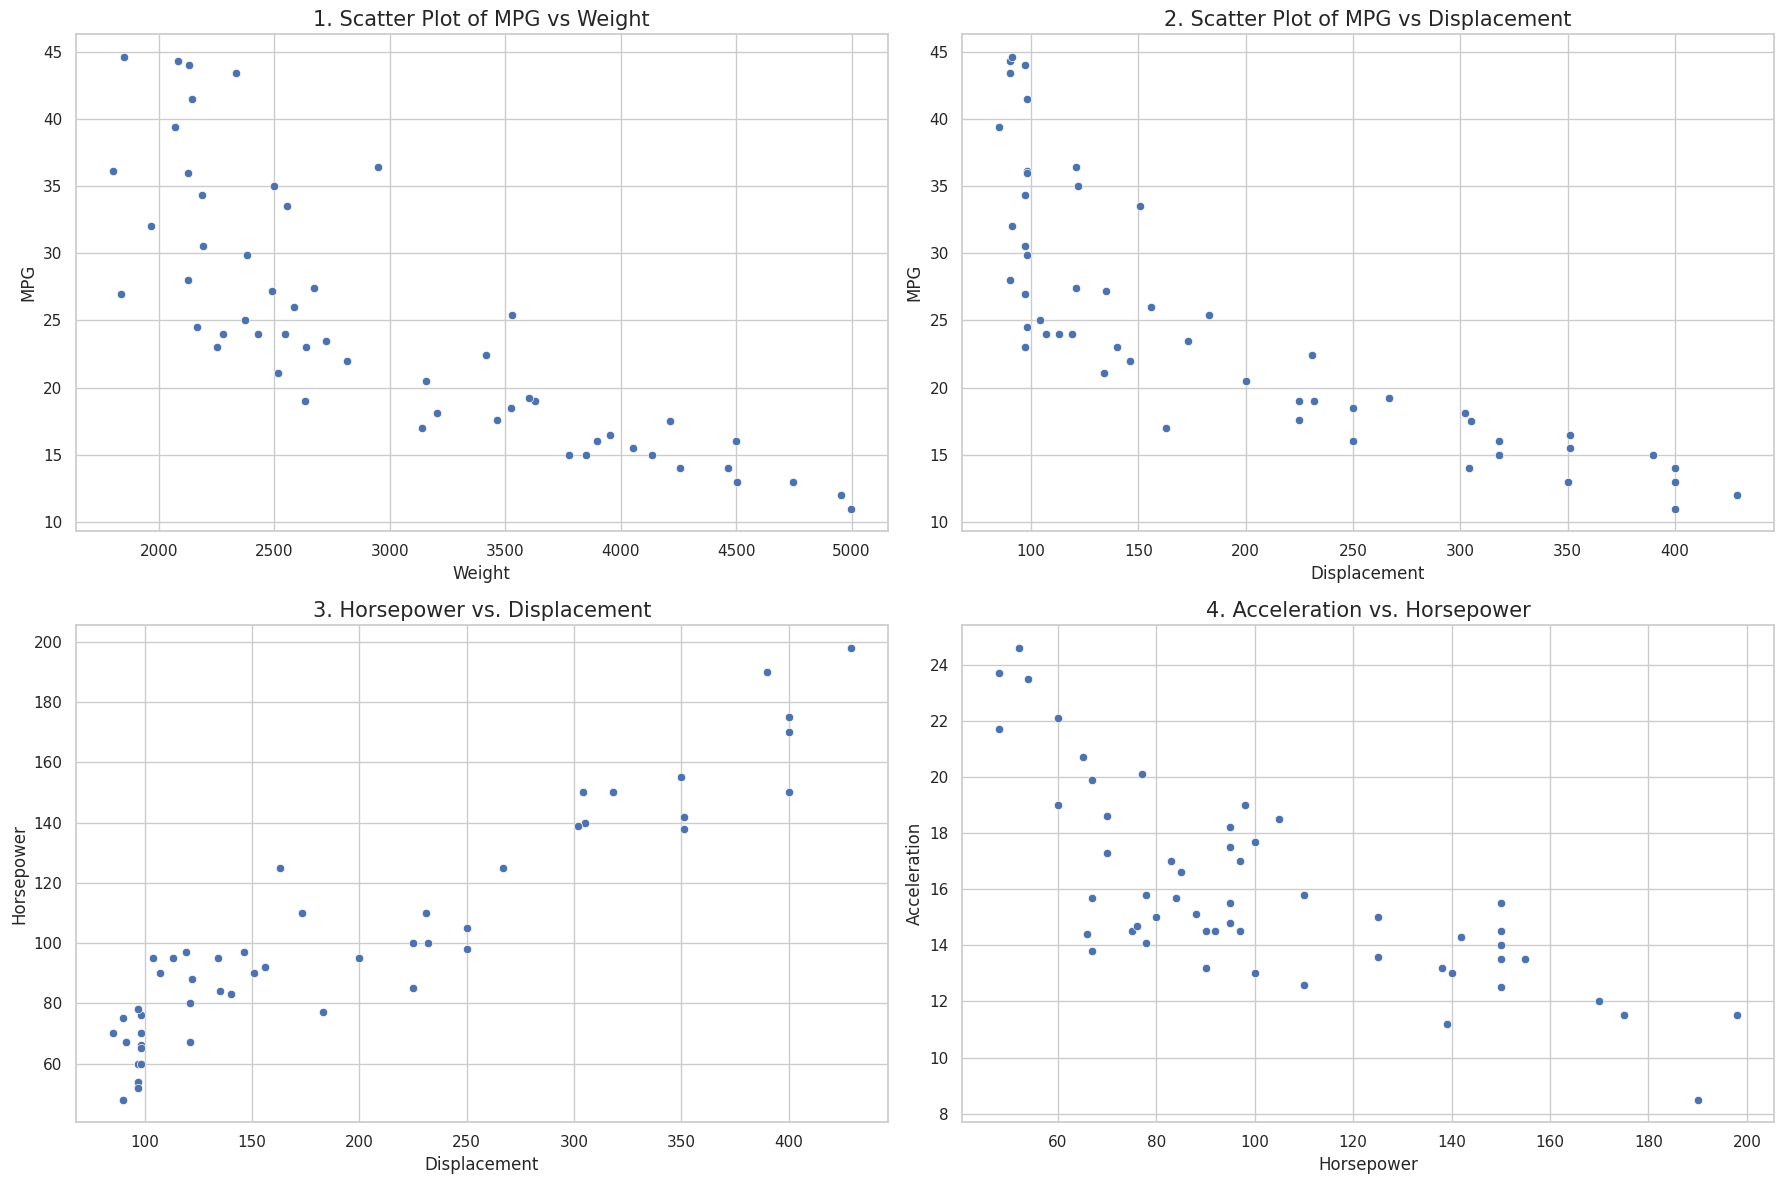

Pearson correlation coefficient (MPG vs. Weight): -0.8071775519720743
Pearson correlation coefficient (MPG vs. Displacement): -0.8055084804325795
Pearson correlation coefficient (Horsepower vs. Displacement): 0.9345363458595437
Pearson correlation coefficient (Acceleration vs. Horsepower): -0.732293409723628


In [ ]:
# Scatter plots and Pearson correlation for a pair of variables
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# MPG vs Weight
sns.scatterplot(x='weight', y='mpg', data=auto_mpg_df, ax=axs[0, 0])
axs[0, 0].set_title('1. Scatter Plot of MPG vs Weight', fontsize=15)
axs[0, 0].set_xlabel('Weight', fontsize=12)
axs[0, 0].set_ylabel('MPG', fontsize=12)

# MPG vs Displacement
sns.scatterplot(x='displacement', y='mpg', data=auto_mpg_df, ax=axs[0, 1])
axs[0, 1].set_title('2. Scatter Plot of MPG vs Displacement', fontsize=15)
axs[0, 1].set_xlabel('Displacement', fontsize=12)
axs[0, 1].set_ylabel('MPG', fontsize=12)

# Horsepower vs. Displacement
sns.scatterplot(data=auto_mpg_df, x='displacement', y='horsepower', ax=axs[1, 0])
axs[1, 0].set_title('3. Horsepower vs. Displacement', fontsize=15)
axs[1, 0].set_xlabel('Displacement', fontsize=12)
axs[1, 0].set_ylabel('Horsepower', fontsize=12)

# Acceleration vs. Horsepower
sns.scatterplot(data=auto_mpg_df, x='horsepower', y='acceleration', ax=axs[1, 1])
axs[1, 1].set_title('4. Acceleration vs. Horsepower', fontsize=15)
axs[1, 1].set_xlabel('Horsepower', fontsize=12)
axs[1, 1].set_ylabel('Acceleration', fontsize=12)

plt.tight_layout()
plt.show()

# Calculating Pearson correlation coefficients
pearson_weight_mpg = auto_mpg_df['weight'].corr(auto_mpg_df['mpg'])
pearson_displacement_mpg = auto_mpg_df['displacement'].corr(auto_mpg_df['mpg'])
hp_disp_corr = auto_mpg_df['horsepower'].corr(auto_mpg_df['displacement'])
acc_hp_corr = auto_mpg_df['acceleration'].corr(auto_mpg_df['horsepower'])

# Display Pearson correlation coefficients
print(f"Pearson correlation coefficient (MPG vs. Weight): {pearson_weight_mpg}")
print(f"Pearson correlation coefficient (MPG vs. Displacement): {pearson_displacement_mpg}")
print(f"Pearson correlation coefficient (Horsepower vs. Displacement): {hp_disp_corr}")
print(f"Pearson correlation coefficient (Acceleration vs. Horsepower): {acc_hp_corr}")

  ### Cross-tabulation: origin and cylinders

In the following phase of our analysis, we use a crosstab to evaluate the associations between two categorical variables, in this instance Origin and Cylinders. This allows us to examine how variables overlap and how frequently they occur in different combinations.

Based on the crosstab heatmap:

**4 Cylinder**: The majority of Origin 2 cars are 4 cylinder, reflecting a trend towards smaller, more fuel-efficient engines in this segment. Origin 1 likewise contains a considerable number of 4-cylinder cars, whilst Origin 3 has the fewest, indicating distinct market preferences.

**6 Cylinder**: The most prevalent in Origin 1, but considerably less common in Origins 2 and 3, reflecting the preferred balance of efficiency and power in Origin 1 manufacturing.

**8 Cylinder**: The Origin 1 has the highest incidence of 8-cylinder engines, which might imply a market group that wants more powerful and bigger cars.

The intensity of the colours in the heat map indicates the quantity of each type of cylinder at the seed locations, offering a visual representation of the data.

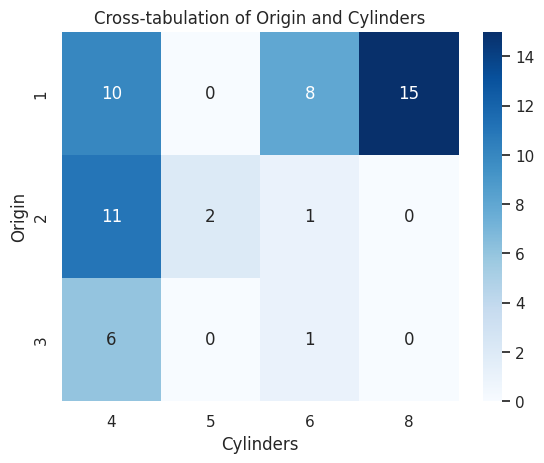

In [ ]:
# Cross-tabulation of Origin and Cylinders
origin_cylinders_ct = pd.crosstab(auto_mpg_df['origin'], auto_mpg_df['cylinders'])

# Heatmap to visualize the cross-tabulation
sns.heatmap(origin_cylinders_ct, annot=True, cmap='Blues', fmt='g')
plt.title('Cross-tabulation of Origin and Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Origin')
plt.show()

### Correlation heatmap

In the following part of our analysis, we utilise a heat map to visualise the correlation matrix in order to quickly and clearly grasp the correlations among various continuous variables.

Based on the heat map analysis:

**MPG vs. other factors**: Dark red tints suggest -0.81 correlations between MPG and displacement, power, and weight. This suggests that as cars and engines become heavier, more precise ones are required, resulting in worse fuel efficiency.

**Displacement, Power, and Weigh**t: These variables are represented in blue. There is a positive connection between displacement and weight (0.95) and power and weight (0.88). This also supports our previous findings that cars with larger and more powerful engines weigh more.

**Acceleration**: Connections with other characteristics are mixed (0.50), implying that more efficient cars accelerate quicker. On the other hand, the negative link between engine size, power, and weight indicates that more powerful cars do not generally accelerate more quickly.

A heat map efficiently captures the complicated relationships between variables, offering a visual summary that may be used for further analysis.

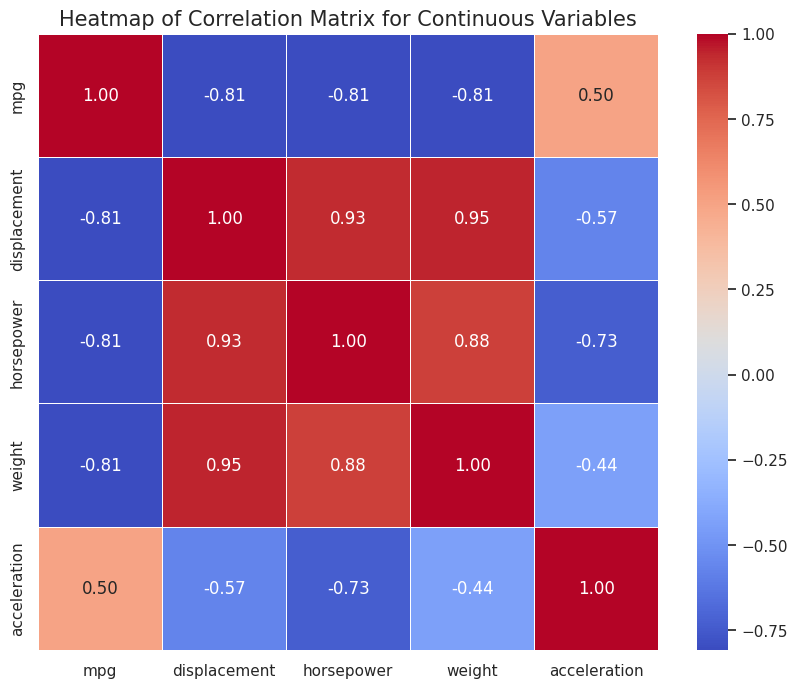

In [ ]:
# Calculating the correlation matrix for continuous variables
continuous_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
correlation_matrix = auto_mpg_df[continuous_cols].corr()

# Creating a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5, fmt=".2f")
plt.title('Heatmap of Correlation Matrix for Continuous Variables', fontsize=15)
plt.show()

### Pairwise relationships

In the following part of our analysis, we utilise a paired plots were selected because they can show both the distribution and relationship of continuous variables. This visualisation method is particularly beneficial for discovering a data set's structure and linkages.

Based on the matched graphs:

**Diagonal histograms** provide a visual depiction. The distribution of MPG and acceleration looks nicely balanced, indicating a wide range of values. The appropriate power and weight bias entails a concentration of cars with smaller engines, less power, and less weight, as well as a smaller number of heavier and more powerful vehicles.

**Scatterplots**. Explain the link between the variables. MPG is inversely related to displacement, horsepower, and weight, indicating a tendency towards increasing power and size at the price of fuel efficiency. The fact that more powerful engines are heavier and produce more power confirms the positive link between displacement, power, and weight.

**Acceleration**. The link between acceleration and other factors is complicated. Its slight positive association with mpg shows that automobiles with higher fuel efficiency may have faster acceleration. However, its negative association with engine size, power, and weight may imply that acceleration performance falls as cars get larger and more powerful.

**Outliers and clusters**. We can identify probable outliers or clusters in the acceleration versus power graph, which indicate automobiles with unusual performance characteristics.

**Approach to analysis**. These paired plots provide useful visual aids for early research, assisting in the identification of trends and highlighting promising areas for additional statistical examination.

In this way, pairwise plots give a comprehensive picture of data dynamics, allowing us to identify linkages that are crucial to taking an educated approach.

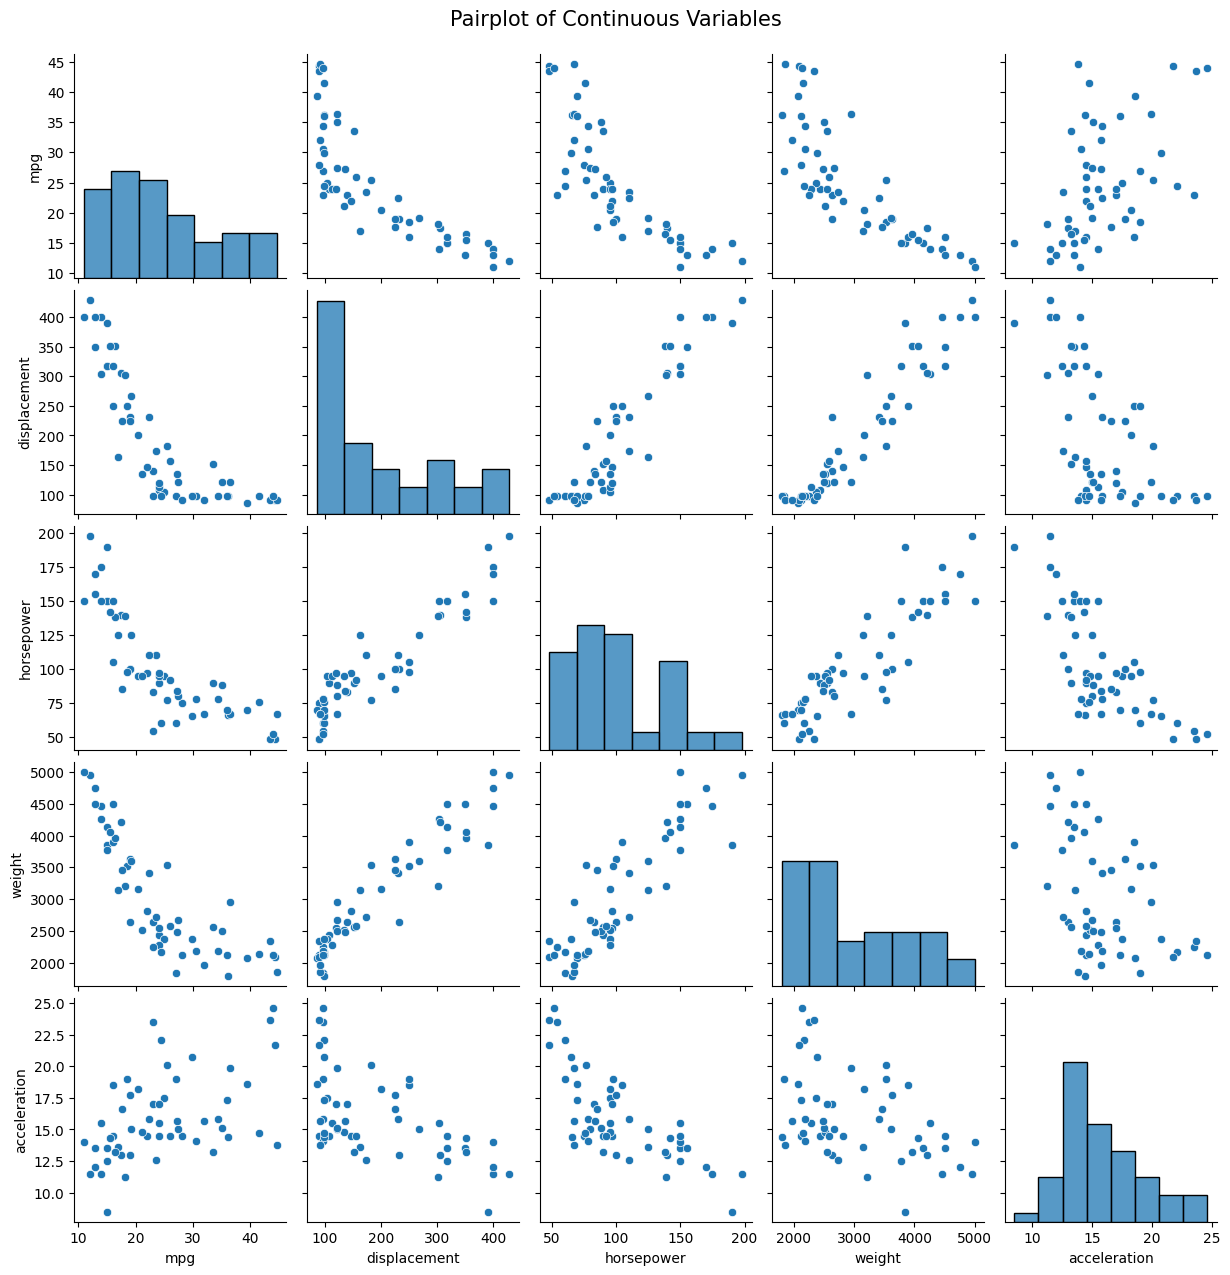

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define continuous columns
continuous_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# Pairplot for continuous variables
sns.pairplot(auto_mpg_df[continuous_cols])
plt.suptitle('Pairplot of Continuous Variables', y=1.02, fontsize=15)
plt.show()

## Conclusion

This analysis offered a thorough understanding of the dataset's properties. We learned about how car factors like weight, power, and engine size impact fuel efficiency and performance. The detected patterns and correlations are statistically valid and provide an accurate view of the data's complicated dynamics. This complex approach not only addressed particular issues regarding the nature of the data set variables but also cleared the path for more complicated modelling and forecasting; users are now ready to make data-driven decisions and adopt more detailed market strategies.